In [1]:
import numpy as np

In [2]:
## 写一个数组
one_array = np.array([1,2,1])
mul_array = np.array(([1,2,1],[2,3,2],[3,4,3]))
display(one_array,mul_array)

array([1, 2, 1])

array([[1, 2, 1],
       [2, 3, 2],
       [3, 4, 3]])

In [3]:
## 寻找最大值
max_value1 = np.max(one_array)
max_value2 = np.max(mul_array)
# 打印结果
print("one_array最大值:", max_value1)
print("mul_array最大值:", max_value2)

one_array最大值: 2
mul_array最大值: 4


In [4]:
arr_1d_expanded = np.expand_dims(max_value2, axis=0)  # 增加一个维度
print("维度上升后的数组:")
print(arr_1d_expanded)

# 维度计算
print("数组的维度:", arr_1d_expanded.ndim)

维度上升后的数组:
[4]
数组的维度: 1


In [5]:
# 基本数学运算
arr = np.array([1, 2, 3])
print("数组加法:", arr + 2)
print("数组减法:", arr - 2)
print("数组乘法:", arr * 2)
print("数组除法:", arr / 2)

# 数组之间的运算
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])
print("数组相加:", arr1 + arr2)
print("数组相减:", arr1 - arr2)
print("数组相乘:", arr1 * arr2)
print("数组相除:", arr1 / arr2)

数组加法: [3 4 5]
数组减法: [-1  0  1]
数组乘法: [2 4 6]
数组除法: [0.5 1.  1.5]
数组相加: [5 7 9]
数组相减: [-3 -3 -3]
数组相乘: [ 4 10 18]
数组相除: [0.25 0.4  0.5 ]


In [6]:
# 矩阵 reshape
arr = np.array([1, 2, 3, 4, 5, 6])
reshaped_arr = arr.reshape(2, 3)
print("reshape后的矩阵:")
print(reshaped_arr)

reshape后的矩阵:
[[1 2 3]
 [4 5 6]]


In [7]:
# 矩阵维度转换
arr = np.array([[1, 2, 3], [4, 5, 6]])

# 转置矩阵
transposed_arr = arr.T
print("转置后的矩阵:")
print(transposed_arr)

# 改变形状
flattened_arr = arr.flatten()  # 展平为一维数组
print("展平后的数组:")
print(flattened_arr)

转置后的矩阵:
[[1 4]
 [2 5]
 [3 6]]
展平后的数组:
[1 2 3 4 5 6]


In [8]:
import torch

# 检查是否支持 CUDA（GPU）
print("CUDA 是否可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("当前设备:", torch.cuda.get_device_name(0))

# 创建一个随机张量
tensor1 = torch.rand(3, 3)  # 3x3 的随机张量
print("随机张量 tensor1:\n", tensor1)

# 创建一个全零张量
tensor2 = torch.zeros(3, 3)
print("全零张量 tensor2:\n", tensor2)

# 张量相加
result = tensor1 + tensor2
print("张量相加结果:\n", result)

# 将张量移动到 GPU（如果可用）
if torch.cuda.is_available():
    tensor1 = tensor1.to("cuda")
    tensor2 = tensor2.to("cuda")
    print("张量已移动到 GPU")
    print("tensor1 在 GPU 上:\n", tensor1)

CUDA 是否可用: True
当前设备: NVIDIA GeForce RTX 2050
随机张量 tensor1:
 tensor([[0.1198, 0.4543, 0.9212],
        [0.7322, 0.8416, 0.3311],
        [0.2278, 0.7603, 0.8920]])
全零张量 tensor2:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
张量相加结果:
 tensor([[0.1198, 0.4543, 0.9212],
        [0.7322, 0.8416, 0.3311],
        [0.2278, 0.7603, 0.8920]])
张量已移动到 GPU
tensor1 在 GPU 上:
 tensor([[0.1198, 0.4543, 0.9212],
        [0.7322, 0.8416, 0.3311],
        [0.2278, 0.7603, 0.8920]], device='cuda:0')


## 线性回归作业

In [3]:
import pandas as pd

In [4]:
data_train = pd.read_csv("test.txt", sep="\t",header=None)
data_train.columns=['x', 'y']
print(data_train)
print("-"*80)

data_test = pd.read_csv("test.txt", sep="\t",header=None)
data_test.columns=['x', 'y']
print(data_test)

         x         y
0     0.10   0.39950
1     0.20   0.79601
2     0.45   1.75490
3     0.60   2.29393
4     0.85   3.10384
..     ...       ...
195  24.70  23.44192
196  24.75  23.62961
197  24.80  23.82009
198  24.85  24.01303
199  24.90  24.20806

[200 rows x 2 columns]
--------------------------------------------------------------------------------
         x         y
0     0.10   0.39950
1     0.20   0.79601
2     0.45   1.75490
3     0.60   2.29393
4     0.85   3.10384
..     ...       ...
195  24.70  23.44192
196  24.75  23.62961
197  24.80  23.82009
198  24.85  24.01303
199  24.90  24.20806

[200 rows x 2 columns]


In [5]:
import numpy as np

# 最小二乘法
def least_square(X,y):
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w

# 多项式基函数
def multinomial_basis(x, feature_num=10):
    x = np.expand_dims(x, axis=1)  # shape(N, 1)
    feat = [x]  # 将数组看作一个元素装入list，此时feat大小为1
    for i in range(2, feature_num + 1):
        feat.append(x ** i)     # 加入数组的2次幂--->10次幂
    ret = np.concatenate(feat, axis=1)  # feat中每个元素都是一个数组，将数组在行上拼接
    return ret

# 高斯基函数
def gaussian_basis(x, feature_num=10):
    centers = np.linspace(0, 25, feature_num)   # (10,)

    width = 1.0 * (centers[1] - centers[0])
    x = np.expand_dims(x, axis=1)
    x = np.concatenate([x] * feature_num, axis=1)   # x看作一个元素装入list，扩展成10个x元素，在行上拼接,变成（300，10）

    out = (x - centers) / width
    ret = np.exp(-0.5 * out ** 2)
    return ret


In [18]:
# 原始矩阵增广
data_train['b'] = [1] * len(data_train)
data_train_x  = data_train[['x','b']]
print(data_train)

data_test['b'] = [1] * len(data_test)
data_test_x  = data_test[['x','b']]
print(data_test)

         x         y  b
0     0.10   0.39950  1
1     0.20   0.79601  1
2     0.45   1.75490  1
3     0.60   2.29393  1
4     0.85   3.10384  1
..     ...       ... ..
195  24.70  23.44192  1
196  24.75  23.62961  1
197  24.80  23.82009  1
198  24.85  24.01303  1
199  24.90  24.20806  1

[200 rows x 3 columns]
         x         y  b
0     0.10   0.39950  1
1     0.20   0.79601  1
2     0.45   1.75490  1
3     0.60   2.29393  1
4     0.85   3.10384  1
..     ...       ... ..
195  24.70  23.44192  1
196  24.75  23.62961  1
197  24.80  23.82009  1
198  24.85  24.01303  1
199  24.90  24.20806  1

[200 rows x 3 columns]


In [19]:
#最小二乘法
least_square(data_train_x,data_train.y)

0    0.934337
1    0.876449
dtype: float64

In [20]:
# 多项式基函数
x = multinomial_basis(data_train.x,feature_num=10)
data_train_x_mul  = pd.concat([pd.DataFrame(x),data_train.b],axis=1)
print(data_train_x_mul)
least_square(data_train_x_mul,data_train.y)

         0         1             2              3             4             5  \
0     0.10    0.0100      0.001000       0.000100  1.000000e-05  1.000000e-06   
1     0.20    0.0400      0.008000       0.001600  3.200000e-04  6.400000e-05   
2     0.45    0.2025      0.091125       0.041006  1.845281e-02  8.303766e-03   
3     0.60    0.3600      0.216000       0.129600  7.776000e-02  4.665600e-02   
4     0.85    0.7225      0.614125       0.522006  4.437053e-01  3.771495e-01   
..     ...       ...           ...            ...           ...           ...   
195  24.70  610.0900  15069.223000  372209.808100  9.193582e+06  2.270815e+08   
196  24.75  612.5625  15160.921875  375232.816406  9.287012e+06  2.298536e+08   
197  24.80  615.0400  15252.992000  378274.201600  9.381200e+06  2.326538e+08   
198  24.85  617.5225  15345.434125  381334.038006  9.476151e+06  2.354823e+08   
199  24.90  620.0100  15438.249000  384412.400100  9.571869e+06  2.383395e+08   

                6          

0     2.489628e+01
1    -2.092267e+01
2     7.695955e+00
3    -1.505584e+00
4     1.731656e-01
5    -1.220073e-02
6     5.270719e-04
7    -1.338256e-05
8     1.778056e-07
9    -8.941256e-10
10   -4.817777e+00
dtype: float64

In [164]:
# 高斯基函数
x = gaussian_basis(data_train.x,feature_num=10)
data_train_x_gaus  = pd.concat([pd.DataFrame(x),data_train.b],axis=1)
# print(data_train_x_gaus)
least_square(data_train_x_gaus,data_train.y)

0    -28.099486
1     25.759973
2    -52.414939
3     51.623169
4    -65.219557
5     57.114666
6    -53.847065
7     38.984672
8    -23.854287
9     12.549423
10    20.765441
dtype: float64

In [42]:
import numpy as np
print(data_train_x)
print(data_train.y.shape)

         x  b
0     0.10  1
1     0.20  1
2     0.45  1
3     0.60  1
4     0.85  1
..     ... ..
195  24.70  1
196  24.75  1
197  24.80  1
198  24.85  1
199  24.90  1

[200 rows x 2 columns]
(200,)


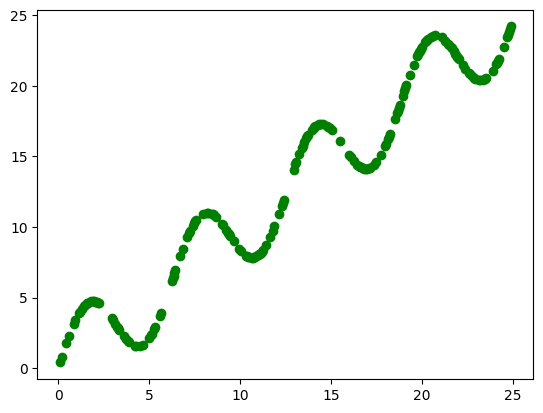

In [26]:
import matplotlib.pyplot as plt
plt.scatter(data_train.x, data_train.y, color='green', label='Training data')

In [55]:
pd.DataFrame(data_train.y)

,y
0,0.39950
1,0.79601
2,1.75490
3,2.29393
4,3.10384
...,...
195,23.44192
196,23.62961
197,23.82009
198,24.01303


In [174]:
# 定义损失函数
def fun(W, X, Y):
    predictions = np.dot(X, W)
    errors = Y - predictions
    # print("预测值",predictions)
    loss = np.sum(errors ** 2) / 2
    # print(errors)
    return loss

# 风险最小化R(w)对w的偏导
def grad(W, X, Y):
    # print("w---------------/n",W)
    predictions = np.dot(X, W)
    errors = Y - predictions
    gradient = -np.dot(X.T, np.nan_to_num(errors))
    return gradient

# 梯度下降优化函数
def gradient_descent(X, Y, learning_rate=0.000001, iterations=10000):
    W = np.zeros((X.shape[1],1))  # 初始化权重向量，考虑了偏置项
    # print("w初始值---------------/n",W)
    for i in range(iterations):
        gradient = grad(W, X, Y)
        # print("w调整前---------------/n",W)
        # print("gradient---------------/n",gradient)
        W -= learning_rate * gradient  # 更新权重
        # W -= learning_rate   # 更新权重
        # print("w调整后---------------/n",W)

        # if i % 100 == 0:  # 打印每100次迭代后的损失值
        #     loss = fun(W, X, Y)
        #     print(f"Iteration {i}: Loss={loss}")
            # if loss < 0.0001:
            #     return W
    # print(W)
    return W

# 应用梯度下降法
W_optimal = gradient_descent(data_train_x, pd.DataFrame(data_train.y), learning_rate=0.000001, iterations=10000)

In [151]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data_train_x.values
y = data_train.y.values

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 定义模型
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train_scaled.shape[1],))
])

# 编译模型
model.compile(optimizer='sgd', loss='mean_squared_error')

# 训练模型
history = model.fit(X_train_scaled, y_train, epochs=100, verbose=0)

# 评估模型
loss = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss}")

# 获取模型的权重和偏置
W = model.layers[0].get_weights()[0]
b = model.layers[0].get_weights()[1]
print(f"拟合的权重: {W[0][0]}, 拟合的偏置: {b[0]}")


predictions = model.predict(data_test_x.values).flatten()

# 计算预测误差
errors = predictions - data_test.y.values

# 计算标准差
std_dev = np.std(errors)
print(f"预测误差的标准差: {std_dev}")

Test Loss: 4.627964973449707
拟合的权重: 6.977846145629883, 拟合的偏置: 13.055377960205078
7/7 [==============================] - 0s 744us/step
预测误差的标准差: 43.91699866038783


In [172]:
## 函数测试
def test_method(fun,X,y):
    # print(X@fun)
    # print(y)
    loss = np.std((X@fun).values-pd.DataFrame(y).values)
    print("损失标准差为:",loss)

In [175]:
# 梯度下降
test_method(gradient_descent(data_train_x,pd.DataFrame(data_train.y)),data_test_x,data_test.y)

损失标准差为: 2.160154636986684


In [169]:
## 最小二乘法
w = np.matrix(least_square(data_train_x,data_train.y)).T
test_method(w,data_test_x,data_test.y)

损失标准差为: 2.1491615539832174


In [178]:
# 高斯基函数
x = gaussian_basis(data_test.x,feature_num=10)
data_test_x_gaus  = pd.concat([pd.DataFrame(x),data_train.b],axis=1)
# print(data_test_x_gaus)
w = np.matrix(least_square(data_train_x_gaus,data_train.y)).T
test_method(w,data_test_x_gaus,data_test.y)

损失标准差为: 0.38323612319704875


In [171]:
# 多项式基函数
x = multinomial_basis(data_test.x,feature_num=10)
data_test_x_mul  = pd.concat([pd.DataFrame(x),data_train.b],axis=1)
w = np.matrix(least_square(data_train_x_mul,data_train.y)).T
test_method(w,data_test_x_mul,data_test.y)

损失标准差为: 1.5545833201014607
